In [7]:
import kagglehub

dataset_path = kagglehub.dataset_download("salader/dogs-vs-cats")

In [8]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv1D,Conv2D,Flatten,Dense,MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization, Dropout, Input, Activation, Add # Importing Input, Activation and Add
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, r2_score
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.datasets.mnist import load_data
from keras.datasets.fashion_mnist import load_data
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential, Model # Importing Model
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [9]:
!ln -s $dataset_path"/train" "/content/"
!ln -s $dataset_path"/test" "/content/"

train_ds=keras.utils.image_dataset_from_directory(
    directory="/content/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)
validation_ds=keras.utils.image_dataset_from_directory(
    directory="/content/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)
def normalize_process(image,label):
  image=tf.cast(image/255.,tf.float32)
  return image, label
train_ds=train_ds.map(normalize_process)
validation_ds=validation_ds.map(normalize_process)

ln: failed to create symbolic link '/content/train': File exists
ln: failed to create symbolic link '/content/test': File exists
Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [4]:
model = Sequential()
# Change input_shape to (256, 256, 3) to match the dataset
model.add(Conv2D(64, kernel_size=(3, 3), strides=1, padding="same", activation="relu", input_shape=(256, 256, 3)))
model.add(Conv2D(64, kernel_size=(3, 3), strides=1, padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3), strides=2))
# Change input_shape to (None, None, 3) to match the dataset
model.add(Conv2D(128, kernel_size=(3, 3), strides=1, padding="same", activation="relu", input_shape=(None, None, 3)))
model.add(Conv2D(128, kernel_size=(3, 3), strides=1, padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3), strides=2))
# Change input_shape to (None, None, 3) to match the dataset
model.add(Conv2D(256, kernel_size=(3, 3), strides=1, padding="same", activation="relu", input_shape=(None, None, 3)))
model.add(Conv2D(256, kernel_size=(3, 3), strides=1, padding="same", activation="relu"))
model.add(Conv2D(256, kernel_size=(3, 3), strides=1, padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3), strides=2))
model.add(Conv2D(512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3), strides=2))
model.add(Conv2D(512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3), strides=2))
model.add(Flatten())
model.add(Dense(25088, activation="relu"))
model.add(Dense(4096, activation="relu"))
model.add(Dense(4096, activation="relu"))
# Change output layer to have 1 unit with sigmoid for binary classification
model.add(Dense(1, activation="sigmoid")) # Updated output layer

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 256, 256, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 127, 127, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 127, 127, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 63, 63, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 63, 63, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 63, 63, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 63, 63, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 31, 31, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 31, 31, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 31, 31, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 31, 31, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 31, 31, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 768,417,089 (2.86 GB)

 Trainable params: 768,417,089 (2.86 GB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer="adam", metrics=["accuracy"], loss="binary_crossentropy")

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10


In [6]:
from tensorflow.keras.applications import ResNet50

In [7]:
r50model = ResNet50(include_top=False, input_shape=(256,256,3))
r50model.trainable=False
model = Sequential([r50model])
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dense(512, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 8, 8, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 131072)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │     134,218,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 158,331,777 (603.99 MB)

 Trainable params: 134,744,065 (514.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
model.compile(optimizer="adam", metrics=["accuracy"], loss="binary_crossentropy")

In [10]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 158ms/step - accuracy: 0.5699 - loss: 3.2348 - val_accuracy: 0.6220 - val_loss: 0.6433
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 153ms/step - accuracy: 0.5464 - loss: 0.6815 - val_accuracy: 0.6732 - val_loss: 0.6028
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.6285 - loss: 0.6392 - val_accuracy: 0.6730 - val_loss: 0.6039
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.6783 - loss: 0.5969 - val_accuracy: 0.7156 - val_loss: 0.5638
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 145ms/step - accuracy: 0.6894 - loss: 0.5818 - val_accuracy: 0.7192 - val_loss: 0.5533
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.7039 - loss: 0.5679 - val_accuracy: 0.7112 - val_loss: 0.5673
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.7221 - loss: 0.5452 - val_accuracy: 0.7130 - val_loss: 0.5832
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.7002 - loss

### RestNetScratch

In [14]:
def ResidualBlock(x, filters, strides = 1):
  skip = x
  x = Conv2D(filters, 3, strides=strides, padding="same")(x)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)
  x = Conv2D(filters, 3, strides=1, padding="same")(x)
  x = BatchNormalization()(x)

  if strides != 1:
    skip = Conv2D(filters, 1, strides=strides, padding="same")(skip)
    skip = BatchNormalization()(skip)

  x = Add()([x, skip])
  x = Activation("relu")(x)

  return x

In [45]:
def create_restnet(input_shape = (256, 256, 3), num_classes = 2, input_tensor=None):
  input_layer = Input(shape=input_shape)
  x = Conv2D(64, 7, strides=2, padding="same")(input_layer)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)
  x = MaxPooling2D(3, strides=2, padding="same")(x)

  x = ResidualBlock(x, 64)
  x = ResidualBlock(x, 64)
  x = ResidualBlock(x, 128, strides = 2)
  x = ResidualBlock(x, 128)
  x = ResidualBlock(x, 256, strides = 2)
  x = ResidualBlock(x, 256)
  x = ResidualBlock(x, 512, strides = 2)
  x = ResidualBlock(x, 512)
  x = GlobalAveragePooling2D()(x)

  output_layer = Dense(num_classes, activation="softmax")(x)
  model = Model(inputs=input_layer, outputs=output_layer)
  return model


In [46]:
model = create_restnet(input_shape=(256, 256, 3), num_classes=2)
x = model.output  # Get the output of the ResNet model
x = Flatten()(x) # Apply Flatten to the output
x = Dense(1024, activation="relu")(x)
x = Dense(512, activation="relu")(x)
output_layer = Dense(1, activation="sigmoid")(x)

# Create a new Functional model
model = Model(inputs=model.input, outputs=output_layer)

In [47]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_68 (Conv2D)        │ (None, 128, 128, 64)   │          9,472 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_68    │ (None, 128, 128, 64)   │            256 │ conv2d_68[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_57             │ (None, 128, 128, 64)   │              0 │ batch_normalization_6… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 64, 64, 64)     │              0 │ activation_57[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_69 (Conv2D)        │ (None, 64, 64, 64)     │         36,928 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_69    │ (None, 64, 64, 64)     │            256 │ conv2d_69[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_58             │ (None, 64, 64, 64)     │              0 │ batch_normalization_6… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_70 (Conv2D)        │ (None, 64, 64, 64)     │         36,928 │ activation_58[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_70    │ (None, 64, 64, 64)     │            256 │ conv2d_70[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_27 (Add)              │ (None, 64, 64, 64)     │              0 │ batch_normalization_7… │
│                           │                        │                │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_59             │ (None, 64, 64, 64)     │              0 │ add_27[0][0]           │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_71 (Conv2D)        │ (None, 64, 64, 64)     │         36,928 │ activation_59[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_71    │ (None, 64, 64, 64)     │            256 │ conv2d_71[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_60        

 Total params: 11,720,323 (44.71 MB)

 Trainable params: 11,710,723 (44.67 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [48]:
model.compile(optimizer="adam", metrics=["accuracy"], loss="binary_crossentropy")

In [ ]:
history = model.fit(train_ds, epochs=20, validation_data=validation_ds)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 139ms/step - accuracy: 0.5139 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.5260 - loss: 0.6913 - val_accuracy: 0.5854 - val_loss: 0.6823
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.5665 - loss: 0.6833 - val_accuracy: 0.5008 - val_loss: 0.7084
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 145ms/step - accuracy: 0.5950 - loss: 0.6727 - val_accuracy: 0.5000 - val_loss: 0.7243
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 139ms/step - accuracy: 0.6231 - loss: 0.6574 - val_accuracy: 0.5172 - val_loss: 0.7447
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 138ms/step - accuracy: 0.6483 - loss: 0.6408 - val_accuracy: 0.6746 - val_loss: 0.6201
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.6866 - loss: 0.6065 - val_accuracy: 0.6398 - val_loss: 0.6649
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.7156 - los

In [ ]:
test_images = cv2.imread("/content/img_1570.jpg")

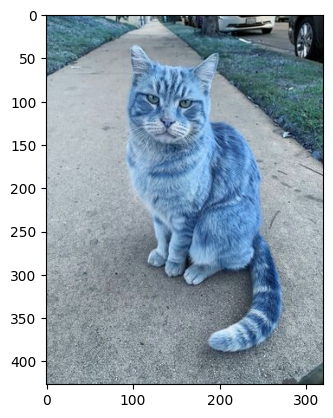

In [ ]:
plt.imshow(test_images)

In [ ]:
test_images = cv2.resize(test_images, (256,256))
test_input = test_images.reshape((1,256,256,3))

In [ ]:
# Assuming test_input is your input image
prediction = model.predict(test_input)

# Set a threshold (e.g., 0.5)
threshold = 0.5

# Classify the image
if prediction > threshold:
    class_label = "dog"
else:
    class_label = "cat"

# Print the prediction and probability
print(f"Prediction: {class_label}, Probability: {prediction[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: cat, Probability: 0.003920009359717369


In [ ]:
test_images2 = cv2.imread("/content/Golden+Retrievers+dans+pet+care.jpeg")

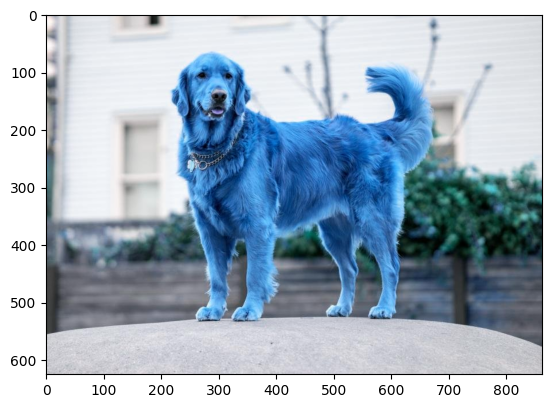

In [ ]:
plt.imshow(test_images2)

In [ ]:
test_images2 = cv2.resize(test_images, (256,256))
test_input2 = test_images2.reshape((1,256,256,3))

In [ ]:
# Assuming test_input is your input image
prediction = model.predict(test_input2)

# Set a threshold (e.g., 0.5)
threshold = 0.5

# Classify the image
if prediction > threshold:
    class_label = "dog"
else:
    class_label = "cat"

# Print the prediction and probability
print(f"Prediction: {class_label}, Probability: {prediction[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: cat, Probability: 0.003920009359717369


In [ ]:
test_images3 = cv2.imread("/content/How_to_Calculate_Your_Cat_s_Age_in_Human_Years_large.jpg")

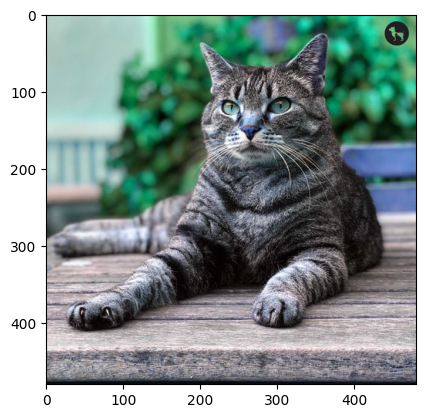

In [ ]:
plt.imshow(test_images3)

In [ ]:
test_images3 = cv2.resize(test_images3, (256,256))
test_input3 = test_images3.reshape((1,256,256,3))

In [ ]:
# Assuming test_input is your input image
prediction = model.predict(test_input3)

# Set a threshold (e.g., 0.5)
threshold = 0.5

# Classify the image
if prediction > threshold:
    class_label = "dog"
else:
    class_label = "cat"

# Print the prediction and probability
print(f"Prediction: {class_label}, Probability: {prediction[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: cat, Probability: 0.003920009359717369
